In [21]:
from tqdm.auto import tqdm

import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as Transforms

from lion_pytorch import Lion
import numpy as np
import matplotlib.pyplot as plt

In [22]:
class Muon(optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95):
        defaults = dict(lr=lr, momentum=momentum)
        super().__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            lr, momentum = group['lr'], group['momentum']
            for p in group['params']:
                if p.grad is None:
                    continue
                g = p.grad
                if p.dim() == 2:
                    g = self._orthogonalize(g)
                state = self.state[p]
                if 'buf' not in state:
                    state['buf'] = torch.zeros_like(g)
                state['buf'].mul_(momentum).add_(g)
                p.data.add_(state['buf'], alpha=-lr)

    @staticmethod
    def _orthogonalize(G, steps=5):
        a, b, c = 3.4445, -4.7750, 2.0315
        X = G / (G.norm() + 1e-7)
        if G.size(0) > G.size(1):
            X = X.T
        for _ in range(steps):
            A = X @ X.T
            X = a * X + (b * A + c * A @ A) @ X
        if G.size(0) > G.size(1):
            X = X.T
        return X.to(G.dtype)

class MuonSGD:
    def __init__(self, muon_params, sgd_params, lr):
        self.muon = Muon(muon_params, lr=lr) if muon_params else None
        self.sgd = optim.SGD(sgd_params, lr=lr) if sgd_params else None

    def zero_grad(self):
        if self.muon:
            self.muon.zero_grad()
        if self.sgd:
            self.sgd.zero_grad()

    def step(self):
        if self.muon:
            self.muon.step()
        if self.sgd:
            self.sgd.step()


def get_optimizer(params, name, lr):
    name = name.lower()
    if name == "sgd":
        return optim.SGD(params, lr=lr)
    if name == "adam":
        return optim.Adam(params, lr=lr)
    if name == "lion":
        return Lion(params, lr=lr)
    if name == "muon":
        params = list(params)
        muon_params = [p for p in params if p.ndim == 2]
        sgd_params = [p for p in params if p.ndim != 2]
        return MuonSGD(muon_params, sgd_params, lr)
    raise ValueError(f"Unknown optimizer: {name}")

In [23]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=(256, 128)):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28 * 28, hidden_sizes[0]), nn.ReLU()]
        for i in range(len(hidden_sizes) - 1):
            layers += [nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]), nn.ReLU()]
        layers.append(nn.Linear(hidden_sizes[-1], 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [43]:
def get_loaders(batch_size):
    transform = Transforms.Compose([Transforms.ToTensor(), Transforms.Normalize((0.5,), (0.5,))])
    train = datasets.FashionMNIST("data", train=True, download=True, transform=transform)
    test = datasets.FashionMNIST("data", train=False, download=True, transform=transform)
    pin = torch.cuda.is_available()
    return (
        DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=pin),
        DataLoader(test, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=pin),
    )

In [39]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total, loss_sum = 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += y.size(0)
        loss_sum += loss.item() * y.size(0)
    return loss_sum / total


# We usually don't care about this in optimization!
def eval_model(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(dim=1) == y).sum().item()
            total += y.size(0)
    return correct / total

In [40]:
def train(opt, batch_size, lr, epochs, device):
    model = MLP().to(device)
    train_loader, test_loader = get_loaders(batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(model.parameters(), opt, lr)

    for epoch in tqdm(range(epochs)):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        test_acc = eval_model(model, test_loader, device)
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - Test Acc: {test_acc:.4f}")

In [41]:
# Grid search parameters
learning_rates = [1e-4, 1e-3, 1e-2]
batch_sizes = [32, 64, 128]
optimizers_to_test = ["sgd", "adam", "lion", "muon"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [32]:
# SGD: lr=1e-02, batch_size=32
# ADAM: lr=1e-03, batch_size=64
# LION: lr=1e-04, batch_size=128
# MUON: lr=1e-03, batch_size=64
def grid_search(learning_rates, batch_sizes, optimizers, epochs, device):
    results = {}
    total_runs = len(learning_rates) * len(batch_sizes) * len(optimizers)
    current_run = 0
    
    for opt in optimizers:
        for lr in learning_rates:
            for bs in batch_sizes:
                current_run += 1
                print(f"\n[{current_run}/{total_runs}] Training {opt.upper()} with lr={lr:.0e}, batch_size={bs}")
                
                model = MLP().to(device)
                train_loader, test_loader = get_loaders(bs)
                criterion = nn.CrossEntropyLoss()
                optimizer = get_optimizer(model.parameters(), opt, lr)
                
                best_loss = float('inf')
                for epoch in tqdm(range(epochs), leave=False):
                    epoch_loss = train_epoch(model, train_loader, criterion, optimizer, device)
                    best_loss = min(best_loss, epoch_loss)
                
                final_acc = eval_model(model, test_loader, device)
                results[(opt, lr, bs)] = (best_loss, final_acc)
                print(f"  Best Loss: {best_loss:.4f}, Final Acc: {final_acc:.4f}")
    
    return results
# grid_search_results = grid_search(learning_rates, batch_sizes, optimizers_to_test, 20, device)

In [33]:
def get_model_params(model):
    params = []
    for p in model.parameters():
        params.append(p.data.cpu().clone().flatten())
    return torch.cat(params)


def set_model_params(model, params_flat):
    offset = 0
    for p in model.parameters():
        numel = p.data.numel()
        p.data = params_flat[offset:offset + numel].reshape(p.data.shape).to(p.device)
        offset += numel


def compute_loss_at_interpolation(model, loader, criterion, theta_start, theta_end, device, num_points):
    model.eval()
    alphas = np.linspace(0, 1, num_points)
    losses = []
    
    with torch.no_grad():
        for alpha in alphas:
            # Interpolate: theta = (1-alpha) * theta_start + alpha * theta_end
            theta_alpha = (1 - alpha) * theta_start + alpha * theta_end
            set_model_params(model, theta_alpha)
            
            # Compute loss on entire loader
            total_loss = 0.0
            total_samples = 0
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                total_loss += loss.item() * y.size(0)
                total_samples += y.size(0)
            
            losses.append(total_loss / total_samples)
    
    return alphas, np.array(losses)


def train_with_epoch_trajectories(opt, batch_size, lr, epochs, device, train_loader, test_loader, criterion):
    model = MLP().to(device)
    optimizer = get_optimizer(model.parameters(), opt, lr)
    
    trajectories = []
    train_losses = []
    
    for epoch in tqdm(range(epochs), desc=f"{opt.upper()}"):
        # Save parameters at epoch start
        theta_epoch_start = get_model_params(model).to(device)
        
        model.train()
        total, loss_sum = 0, 0.0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total += y.size(0)
            loss_sum += loss.item() * y.size(0)
        
        epoch_loss = loss_sum / total
        train_losses.append(epoch_loss)
        
        # Save parameters at epoch end and compute trajectory
        theta_epoch_end = get_model_params(model).to(device)
        interp_x, interp_y = next(iter(train_loader))
        interp_loader = [(interp_x, interp_y)]
        alphas, losses = compute_loss_at_interpolation(model, interp_loader, criterion, theta_epoch_start, theta_epoch_end, device, num_points=20)
        #alphas, losses = compute_loss_at_interpolation(model, train_loader, criterion, theta_epoch_start, theta_epoch_end, device, num_points=50)
        trajectories.append((epoch, alphas, losses))
        
        # Evaluate on test set
        test_acc = eval_model(model, test_loader, device)
        print(f"  Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f} - Test Acc: {test_acc:.4f}")
    
    return model, trajectories, train_losses

In [34]:
best_hyperparams = {
    "sgd": {"lr": 1e-2, "bs": 32},
    "adam": {"lr": 1e-3, "bs": 64},
    "lion": {"lr": 1e-4, "bs": 128},
    "muon": {"lr": 1e-3, "bs": 64},
}

# Train with trajectory analysis for 5 epochs using best hyperparameters
print("=" * 80)
print("TRAJECTORY ANALYSIS: 5 Epochs with Best Hyperparameters")
print("=" * 80)

trajectories_all_optimizers = {}

for opt in optimizers_to_test:
    params = best_hyperparams[opt]
    lr = params["lr"]
    bs = params["bs"]
    
    print(f"\n{opt.upper()}: lr={lr:.0e}, batch_size={bs}")
    print("-" * 40)
    
    train_loader, test_loader = get_loaders(bs)
    criterion = nn.CrossEntropyLoss()
    
    model, trajectories, train_losses = train_with_epoch_trajectories(opt, bs, lr, 5, device, train_loader, test_loader, criterion)
    trajectories_all_optimizers[opt] = trajectories
    
print("\nTrajectory analysis complete!")

TRAJECTORY ANALYSIS: 5 Epochs with Best Hyperparameters

SGD: lr=1e-02, batch_size=32
----------------------------------------


SGD:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1/5 - Train Loss: 0.7654 - Test Acc: 0.8081
  Epoch 2/5 - Train Loss: 0.4720 - Test Acc: 0.8265
  Epoch 3/5 - Train Loss: 0.4250 - Test Acc: 0.8405
  Epoch 4/5 - Train Loss: 0.3954 - Test Acc: 0.8502
  Epoch 5/5 - Train Loss: 0.3741 - Test Acc: 0.8543

ADAM: lr=1e-03, batch_size=64
----------------------------------------


ADAM:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1/5 - Train Loss: 0.4945 - Test Acc: 0.8341
  Epoch 2/5 - Train Loss: 0.3648 - Test Acc: 0.8614
  Epoch 3/5 - Train Loss: 0.3291 - Test Acc: 0.8661
  Epoch 4/5 - Train Loss: 0.3048 - Test Acc: 0.8688
  Epoch 5/5 - Train Loss: 0.2859 - Test Acc: 0.8774

LION: lr=1e-04, batch_size=128
----------------------------------------


LION:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1/5 - Train Loss: 0.7409 - Test Acc: 0.8312
  Epoch 2/5 - Train Loss: 0.3998 - Test Acc: 0.8584
  Epoch 3/5 - Train Loss: 0.3458 - Test Acc: 0.8641
  Epoch 4/5 - Train Loss: 0.3113 - Test Acc: 0.8751
  Epoch 5/5 - Train Loss: 0.2866 - Test Acc: 0.8781

MUON: lr=1e-03, batch_size=64
----------------------------------------


MUON:   0%|          | 0/5 [00:00<?, ?it/s]

  Epoch 1/5 - Train Loss: 0.5364 - Test Acc: 0.8577
  Epoch 2/5 - Train Loss: 0.3887 - Test Acc: 0.8666
  Epoch 3/5 - Train Loss: 0.3904 - Test Acc: 0.8696
  Epoch 4/5 - Train Loss: 0.3879 - Test Acc: 0.8705
  Epoch 5/5 - Train Loss: 0.3921 - Test Acc: 0.8729

Trajectory analysis complete!


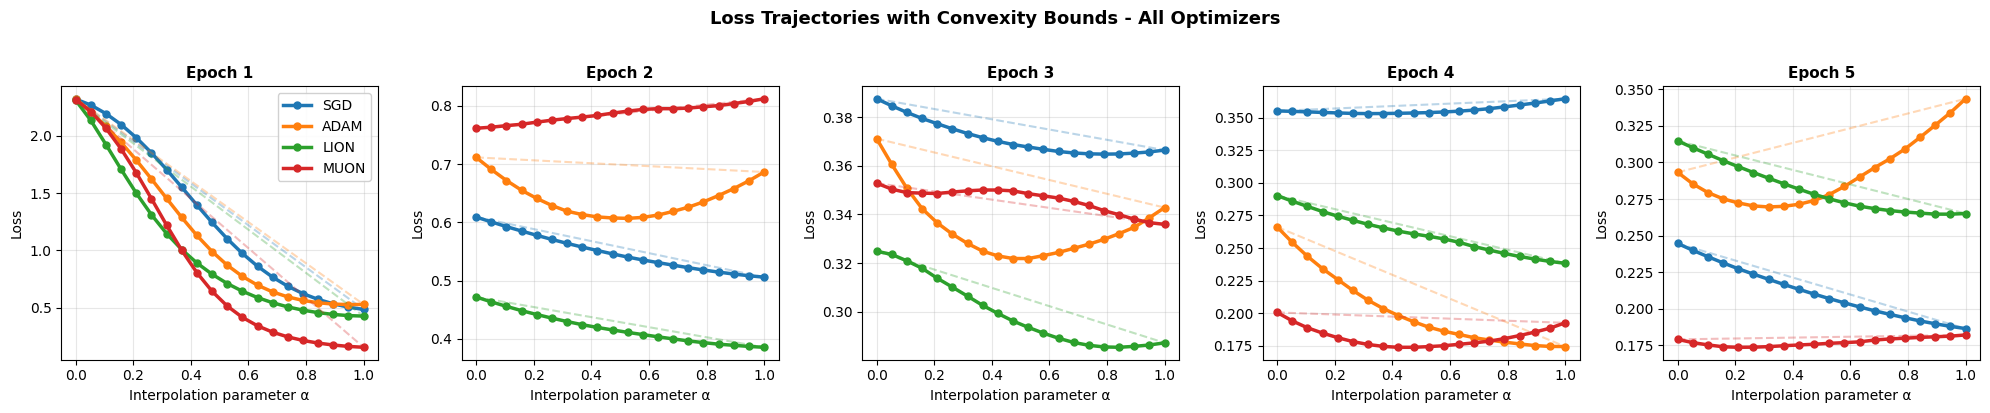


Trajectory plots saved to 'loss_trajectories.png'


In [35]:
# Plot trajectories - one subplot per epoch with all optimizers + convexity bounds
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

optimizer_colors = {'sgd': 'C0', 'adam': 'C1', 'lion': 'C2', 'muon': 'C3'}

# Iterate through epochs
for epoch_idx in range(5):
    ax = axes[epoch_idx]
    
    # Plot each optimizer's trajectory for this epoch
    for opt in optimizers_to_test:
        trajectories = trajectories_all_optimizers[opt]
        if epoch_idx < len(trajectories):
            epoch, alphas, losses = trajectories[epoch_idx]
            
            # Plot trajectory
            ax.plot(alphas, losses, linewidth=2.5, marker='o', markersize=5,
                   label=opt.upper(), color=optimizer_colors[opt])
            
            # Add convexity bound
            convex_line = (1 - alphas) * losses[0] + alphas * losses[-1]
            ax.plot(alphas, convex_line, linewidth=1.5, linestyle='--', 
                   color=optimizer_colors[opt], alpha=0.3)
    
    ax.set_xlabel('Interpolation parameter α', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title(f'Epoch {epoch_idx+1}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Add legend to first subplot
axes[0].legend(loc='best', fontsize=10, framealpha=0.9)

fig.suptitle('Loss Trajectories with Convexity Bounds - All Optimizers', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('loss_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTrajectory plots saved to 'loss_trajectories.png'")

In [36]:
# Analyze convexity and smoothness of trajectories
print("\n" + "=" * 80)
print("TRAJECTORY ANALYSIS: CONVEXITY AND SMOOTHNESS PROPERTIES")
print("=" * 80)

analysis_results = {}

for opt in optimizers_to_test:
    trajectories = trajectories_all_optimizers[opt]
    
    print(f"\n{opt.upper()}:")
    print("-" * 40)
    
    convex_count = 0
    smoothness_scores = []
    
    for epoch, alphas, losses in trajectories:
        # Check convexity: f(α*θ_end + (1-α)*θ_start) ≤ (1-α)*f(θ_start) + α*f(θ_end)
        convex_line = (1 - alphas) * losses[0] + alphas * losses[-1]
        is_convex = np.all(losses <= convex_line + 1e-6)  # small tolerance for numerical errors
        if is_convex:
            convex_count += 1
        
        # Compute smoothness: finite differences of loss along trajectory
        grad_diffs = np.abs(np.diff(losses) / np.diff(alphas))
        smoothness = np.std(grad_diffs)
        smoothness_scores.append(smoothness)
        
        status = "✓ CONVEX" if is_convex else "✗ NON-CONVEX"
        print(f"  Epoch {epoch+1}: {status} | Smoothness: {smoothness:.4f}")
    
    convexity_ratio = (convex_count / len(trajectories)) * 100
    avg_smoothness = np.mean(smoothness_scores)
    
    print(f"\n  Summary:")
    print(f"    Convex epochs: {convex_count}/{len(trajectories)} ({convexity_ratio:.1f}%)")
    print(f"    Avg smoothness: {avg_smoothness:.4f}")
    
    analysis_results[opt] = {
        'convexity': convexity_ratio,
        'smoothness': avg_smoothness
    }

# Print comparison table
print("\n" + "=" * 80)
print("COMPARISON TABLE")
print("=" * 80)
print("\n{:<8} | {:>12} | {:>12}".format("Optimizer", "Convexity %", "Smoothness"))
print("-" * 40)
for opt in optimizers_to_test:
    result = analysis_results[opt]
    print("{:<8} | {:>12.1f} | {:>12.4f}".format(opt.upper(), result['convexity'], result['smoothness']))


TRAJECTORY ANALYSIS: CONVEXITY AND SMOOTHNESS PROPERTIES

SGD:
----------------------------------------
  Epoch 1: ✗ NON-CONVEX | Smoothness: 0.8353
  Epoch 2: ✓ CONVEX | Smoothness: 0.0330
  Epoch 3: ✓ CONVEX | Smoothness: 0.0166
  Epoch 4: ✓ CONVEX | Smoothness: 0.0102
  Epoch 5: ✓ CONVEX | Smoothness: 0.0167

  Summary:
    Convex epochs: 4/5 (80.0%)
    Avg smoothness: 0.1824

ADAM:
----------------------------------------
  Epoch 1: ✓ CONVEX | Smoothness: 1.1227
  Epoch 2: ✓ CONVEX | Smoothness: 0.1099
  Epoch 3: ✓ CONVEX | Smoothness: 0.0555
  Epoch 4: ✓ CONVEX | Smoothness: 0.0674
  Epoch 5: ✓ CONVEX | Smoothness: 0.0522

  Summary:
    Convex epochs: 5/5 (100.0%)
    Avg smoothness: 0.2815

LION:
----------------------------------------
  Epoch 1: ✓ CONVEX | Smoothness: 1.3960
  Epoch 2: ✓ CONVEX | Smoothness: 0.0376
  Epoch 3: ✗ NON-CONVEX | Smoothness: 0.0239
  Epoch 4: ✓ CONVEX | Smoothness: 0.0152
  Epoch 5: ✓ CONVEX | Smoothness: 0.0289

  Summary:
    Convex epochs: 4/5 

In [44]:
def compute_gradient_flat(model, loader, criterion, device):
    model.train()
    model.zero_grad()
    total_loss, total_samples = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        loss = criterion(model(x), y) * y.size(0)
        loss.backward()
        total_loss += loss.item()
        total_samples += y.size(0)
    grads = [p.grad.data.cpu().clone().flatten() / total_samples for p in model.parameters()]
    return torch.cat(grads)


def compute_loss_flat(model, loader, criterion, device):
    model.eval()
    total_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            total_loss += criterion(model(x), y).item() * y.size(0)
            total_samples += y.size(0)
    return total_loss / total_samples


def test_convergence_condition(model, loader, criterion, device, epsilon=0.01, num_samples=50):
    theta_m = get_model_params(model).cpu()
    f_m = compute_loss_flat(model, loader, criterion, device)
    grad_m = compute_gradient_flat(model, loader, criterion, device)

    violations = 0
    for _ in range(num_samples):
        direction = torch.randn_like(theta_m)
        theta_x = theta_m + epsilon * direction / direction.norm()

        set_model_params(model, theta_x.to(device))
        f_x = compute_loss_flat(model, loader, criterion, device)

        rhs = f_x + torch.dot(grad_m, theta_m - theta_x).item()
        if f_m > rhs + 1e-6:
            violations += 1

    set_model_params(model, theta_m.to(device))
    return violations, num_samples


print("=" * 80)
print("CONVERGENCE TEST: f(m) <= f(x) + grad_f(m)^T (m - x) for x in B_eps(m)")
print("=" * 80)

for opt in optimizers_to_test:
    params = best_hyperparams[opt]
    train_loader, _ = get_loaders(params["bs"])
    criterion = nn.CrossEntropyLoss()

    model = MLP().to(device)
    optimizer = get_optimizer(model.parameters(), opt, params["lr"])
    for _ in tqdm(range(10), desc=f"Training {opt.upper()}"):
        train_epoch(model, train_loader, criterion, optimizer, device)

    violations, total = test_convergence_condition(model, train_loader, criterion, device)
    pct = (total - violations) / total * 100
    print(f"{opt.upper():6s}: {violations}/{total} violations  ({pct:.1f}% condition satisfied)")

CONVERGENCE TEST: f(m) <= f(x) + grad_f(m)^T (m - x) for x in B_eps(m)


Training SGD:   0%|          | 0/10 [00:00<?, ?it/s]

SGD   : 0/50 violations  (100.0% condition satisfied)


Training ADAM:   0%|          | 0/10 [00:00<?, ?it/s]

ADAM  : 0/50 violations  (100.0% condition satisfied)


Training LION:   0%|          | 0/10 [00:00<?, ?it/s]

LION  : 0/50 violations  (100.0% condition satisfied)


Training MUON:   0%|          | 0/10 [00:00<?, ?it/s]

MUON  : 0/50 violations  (100.0% condition satisfied)


In [46]:
def estimate_lipschitz(model, loader, criterion, device, n_samples=5):
    L_estimates = []
    params_list = []
    grads_list = []
    
    for i, (x, y) in enumerate(loader):
        if i >= n_samples:
            break
        x, y = x.to(device), y.to(device)
        model.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        grads_list.append(compute_gradient_flat(model, [(x,y)], criterion, device))
        params_list.append(get_model_params(model).clone())
        # perturb params slightly
        noise = torch.randn_like(get_model_params(model)) * 1e-3
        set_model_params(model, (get_model_params(model) + noise).to(device))

    for i in range(len(grads_list)-1):
        dg = (grads_list[i+1] - grads_list[i]).norm().item()
        dp = (params_list[i+1] - params_list[i]).norm().item()
        if dp > 0:
            L_estimates.append(dg / dp)
    
    return np.mean(L_estimates)

print("=" * 80)
print("THEORETICAL vs GRID-SEARCHED LEARNING RATES")
print("=" * 80)

T = 5 * len(get_loaders(64)[0])  # total steps
beta1, beta2 = 0.9, 0.999

theoretical_lr = {
    "sgd":  None,  # filled after L estimation
    "adam": float((1 - beta2)**0.5),
    "lion": float((1 - beta1) * (1 - beta2)**0.5),
    "muon": 0.02,
}

# Estimate L using a trained SGD model
model_tmp = MLP().to(device)
opt_tmp = optim.SGD(model_tmp.parameters(), lr=1e-2)
train_loader_tmp, _ = get_loaders(32)
for _ in range(3):
    train_epoch(model_tmp, train_loader_tmp, nn.CrossEntropyLoss(), opt_tmp, device)

L = estimate_lipschitz(model_tmp, train_loader_tmp, nn.CrossEntropyLoss(), device)
theoretical_lr["sgd"] = 1.0 / L

print(f"\n{'Optimizer':<10} {'Theory LR':>12} {'Grid LR':>12} {'Ratio':>10}")
print("-" * 48)
for opt in optimizers_to_test:
    grid_lr = best_hyperparams[opt]["lr"]
    theory_lr = theoretical_lr[opt]
    ratio = grid_lr / theory_lr
    print(f"{opt.upper():<10} {theory_lr:>12.2e} {grid_lr:>12.2e} {ratio:>10.2f}")


THEORETICAL vs GRID-SEARCHED LEARNING RATES

Optimizer     Theory LR      Grid LR      Ratio
------------------------------------------------
SGD            1.23e-01     1.00e-02       0.08
ADAM           3.16e-02     1.00e-03       0.03
LION           3.16e-03     1.00e-04       0.03
MUON           2.00e-02     1.00e-03       0.05
